In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
import scipy.integrate as integrate
from tqdm import tqdm

Say our incoming temporal mode is a Gaussian, aka $\alpha_{in}=e^{-t^2}$. From Gorshkov's paper, the optimal control pulse shape to store this is then: 

$$\Omega(t)= -\frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}}\frac{\alpha_{in}(t)}{\sqrt{\int_0^T{|\alpha_{in}(t)|^2}}}
\text{exp}(\frac{i\Delta h(t, T)}{\gamma^2(1+C)^2+\Delta^2})$$

$$ \Omega(t) = a \times \alpha \times \text{exp}(\frac{i\Delta h(t, T)}{b})$$

- $\alpha = \frac{\alpha_{in}(t)}{\sqrt{\int_0^T{|\alpha_{in}(t)|^2}}}, a = -\frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}}, b = \gamma^2(1+C)^2+\Delta^2$

with $h(t, T) = \int_t^T |\Omega(t)|^2 dt$.

Note: could be interesting trying to simulate the Gorshkov Hamiltonian

In [2]:
gamma = 1.0       # decay rate
C = 2.0           # cooperativity
Delta = 1.0       # detuning
T = 5.0          # total time
N = 1000          # number of time steps
t = np.linspace(0, T, N)

# Precompute prefactors (constants)
a = -(gamma*(1+C) - 1j*Delta) / np.sqrt(2*gamma*(1+C))
b = gamma**2*(1+C)**2 + Delta**2

# Input field alpha_in(t)
def alpha_in(t):
    return np.exp(-((t - T/2)**2) / (2 * (T/10)**2))  # Gaussian
    #return np.exp(-((t)**2) / 2)  # Gaussian

# Compute alpha
alpha = np.array([])
for t_val in t:
    integral_value, _ = integrate.quad(lambda x: np.abs(alpha_in(x))**2, 0, t_val)
    alpha = np.append(alpha, alpha_in(t_val) / np.sqrt(integral_value) if integral_value > 0 else 0)

In [3]:
# Returns the integral of |Omega|^2 from t[idx] to t[-1]
def get_h(Omega, idx):
    h_val = np.array([])
    for j in range(idx, len(t)):
        integral = np.trapz(np.abs(Omega[idx:-1])**2, t[idx:-1]) # Array of inner function at each time
        h_val = np.append(h_val, integral)
    h_val = np.sum(h_val).astype(dtype=complex)
    return h_val

In [4]:
# Initial Omega(t) guess (all these seem to work)
Omega_guess = alpha_in(t) #a * alpha
Omega_new = np.array([], dtype=complex)

for i in tqdm(range(0, len(t))):
    h_val = get_h(Omega_guess, i)
    exp_term = np.exp(1j*Delta*h_val/b)
    Omega_new = np.append(Omega_new, a * alpha[i] * exp_term)

test = np.array([], dtype=complex)
for i in tqdm(range(0, len(t))):
    h_val = get_h(Omega_new, i)
    exp_term = np.exp(1j*Delta*h_val/b)
    test = np.append(test, Omega_new[i] / (a*exp_term)) # This should equal alpha

# Seems like just one iteration was enough to get the optimal Omega.
'''
difference = np.array([])
for j in range(10):  # 10 iterations (can change this)
    # Update Omega(t)
    Omega_previous = Omega
    Omega = a * alpha_vals/norm_alpha * np.exp(1j*Delta*h_vals/b)
    difference = np.append(difference, np.linalg.norm(Omega - Omega_previous))
    
# Plot result
fig, axs = plt.subplots(1, 2, figsize=(12, 3))
axs[0].plot(t, alpha_vals, label='alpha(t)')
axs[0].plot(t, np.real(Omega), label='Re[Ω(t)]')
axs[0].plot(t, np.imag(Omega), label='Im[Ω(t)]')
axs[0].plot(t, np.abs(Omega), label='Mag[Ω(t)]')
axs[0].set_title('Computed Ω(t)')
axs[0].set_xlabel('Time t')
axs[0].set_ylabel('Ω(t)')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(iterations, difference)
axs[1].set_title('Convergence')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Difference between iterated Ω')
axs[1].grid(True)'''

100%|██████████| 1000/1000 [00:36<00:00, 27.61it/s]


"\ndifference = np.array([])\nfor j in range(10):  # 10 iterations (can change this)\n    # Update Omega(t)\n    Omega_previous = Omega\n    Omega = a * alpha_vals/norm_alpha * np.exp(1j*Delta*h_vals/b)\n    difference = np.append(difference, np.linalg.norm(Omega - Omega_previous))\n    \n# Plot result\nfig, axs = plt.subplots(1, 2, figsize=(12, 3))\naxs[0].plot(t, alpha_vals, label='alpha(t)')\naxs[0].plot(t, np.real(Omega), label='Re[Ω(t)]')\naxs[0].plot(t, np.imag(Omega), label='Im[Ω(t)]')\naxs[0].plot(t, np.abs(Omega), label='Mag[Ω(t)]')\naxs[0].set_title('Computed Ω(t)')\naxs[0].set_xlabel('Time t')\naxs[0].set_ylabel('Ω(t)')\naxs[0].legend()\naxs[0].grid(True)\n\naxs[1].plot(iterations, difference)\naxs[1].set_title('Convergence')\naxs[1].set_xlabel('Iteration')\naxs[1].set_ylabel('Difference between iterated Ω')\naxs[1].grid(True)"

I wouldn't expect $\Omega$ to be completely real but also the graph of just the real/imaginary parts is kind of weird.

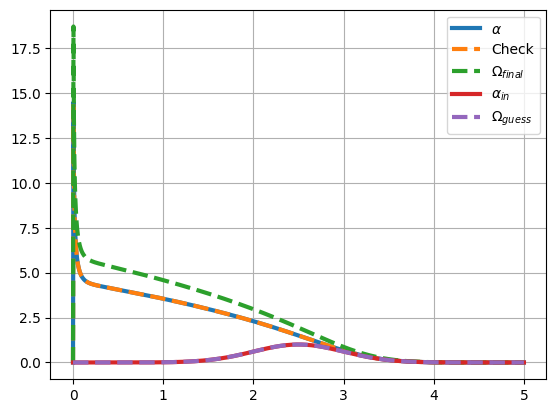

In [5]:
plt.plot(t, alpha, linewidth=3, label=r'$\alpha$')
plt.plot(t, np.abs(test), '--', linewidth=3, label='Check')
plt.plot(t, np.abs(Omega_new[0:len(t)]), '--', linewidth=3, label=r'$\Omega_{final}$')
plt.plot(t, alpha_in(t), linewidth=3, label=r'$\alpha_{in}$')
plt.plot(t, np.abs(Omega_guess[0:len(t)]), '--', linewidth=3, label=r'$\Omega_{guess}$')
plt.legend(); plt.grid()

The physical intuition for why the initial pulse is exponentially large is that you initially have a small signal, so to "write" that signal, it requires a lot of power. 

We expect to have (for storage), eq. (23) in the Gorshkov paper:

$$S(T)=\sqrt{\frac{C}{1+C}} \int_0^T dt f(t)\alpha_{in}(t)$$


where $f(t)= - \frac{\Omega^*(t)\sqrt{2\gamma(1+C)}}{\gamma(1+C)+i\Delta} e^{-h(t,T)/(\gamma(1+C)+i\Delta)}$


In [6]:
Omega = np.copy(Omega_new)
f_prefactor = -np.sqrt(2*gamma*(1+C)) / (gamma*(1+C) + 1j*Delta)

h_vals = np.array([])
for i in tqdm(range(0, len(t))):
    h_vals = np.append(h_vals, get_h(Omega, i)) # list of h(t, T) for different t from 0 to end
f = np.conjugate(Omega) * f_prefactor * np.exp(-h_vals/ (gamma*(1+C) + 1j*Delta))

100%|██████████| 1000/1000 [00:35<00:00, 27.91it/s]


In [7]:
S_analytic = np.array([])
for i in tqdm(range(0, len(t))):
    S_analytic = np.append(S_analytic, np.sqrt(C/(1+C)) * np.array(np.trapz(f[0:i]*alpha_in(t)[0:i], t[0:i])))

100%|██████████| 1000/1000 [00:00<00:00, 8663.36it/s]


Differential equation we want to solve:

$$[\gamma(1+C)+i\Delta]\dot{S} + |\Omega|^2S= -\Omega^* \alpha_{in} \sqrt{2\gamma C}$$
Rearranging,
$$\dot{S} = -\left(\frac{|\Omega|^2}{\gamma(1+C)+i\Delta}\right)S - 
\left(\frac{\Omega^*  \sqrt{2\gamma C}}{\gamma(1+C)+i\Delta}\right) \alpha_{in}$$

I would expect $S=\frac{C}{1+C}$.


In [8]:
def dSdt(t, S):
    coeff_s = -np.abs(Omega_func(t))**2 / (gamma*(1+C) + 1j*Delta)
    coeff_alpha = np.conjugate(Omega_func(t)) * np.sqrt(2*gamma*C) / (gamma*(1+C) + 1j*Delta)
    dsdt = coeff_s * S - coeff_alpha * alpha_in(t)
    return dsdt

Omega_func = interp1d(t, Omega, fill_value="extrapolate")

S0 = 0+0j # At initial time (prior to storage), there is no spin wave stored in the atom (diff results with 0 and 0+0j???)
t_span = (t[0], t[-1])
S = solve_ivp(dSdt, t_span, [S0], t_eval=t)  # evaluate at same times as input

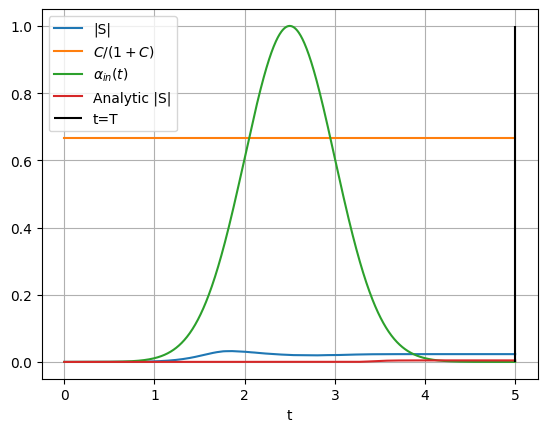

In [10]:
plt.plot(S.t, np.abs(S.y[0]), label='|S|')
#plt.plot(S.t, np.real(S.y[0]), label='Re(S)')
#plt.plot(S.t, np.imag(S.y[0]), label='Im(S)')
plt.plot(S.t, C/(1+C)*np.ones(len(S.t)), label=r'$C/(1+C)$')
plt.plot(t, alpha_in(t), label=r'$\alpha_{in}(t)$')
plt.plot(t, np.abs(S_analytic), label='Analytic |S|')
#plt.ylim(0, 0.1)
plt.vlines([T], 0, 1, 'black', label='t=T')
plt.xlabel('t')
plt.legend(loc='upper left'); plt.grid(); 